In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             average_precision_score, classification_report)
import matplotlib.pyplot as plt

In [2]:
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


### 1. Load & explore data

In [3]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target        # 569 samples, 30 features; y=1 benign
print(X.shape, "class balance:", np.bincount(y))   # slight imbalance
print(X.describe().T.head())          # quick numeric summary

(569, 30) class balance: [212 357]
                 count        mean         std        min        25%  \
mean radius      569.0   14.127292    3.524049    6.98100   11.70000   
mean texture     569.0   19.289649    4.301036    9.71000   16.17000   
mean perimeter   569.0   91.969033   24.298981   43.79000   75.17000   
mean area        569.0  654.889104  351.914129  143.50000  420.30000   
mean smoothness  569.0    0.096360    0.014064    0.05263    0.08637   

                       50%       75%        max  
mean radius       13.37000   15.7800    28.1100  
mean texture      18.84000   21.8000    39.2800  
mean perimeter    86.24000  104.1000   188.5000  
mean area        551.10000  782.7000  2501.0000  
mean smoothness    0.09587    0.1053     0.1634  


In [11]:
X.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

### Train / validation / test split (stratified)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
# Carve a validation set out of train for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

### 3A. scikit-learn API (recommended for most users) early_stopping_rounds & eval_metric are CONSTRUCTOR args

In [6]:
clf = xgb.XGBClassifier(
    n_estimators=2000,          # upper bound; early stopping finds the real number
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="binary:logistic",
    eval_metric="aucpr",        # AUC-PR: good for mild imbalance
    tree_method="hist",         # default since 2.0; add device="cuda" for GPU
    early_stopping_rounds=50,   # constructor arg in modern XGBoost
    random_state=42,
)
clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)
print("Best iteration:", clf.best_iteration)
print("Best score:", clf.best_score)

[0]	validation_0-aucpr:0.95995


[52]	validation_0-aucpr:0.99186
Best iteration: 2
Best score: 0.9925116166043841


### Prediction automatically uses the best iteration when early stopping is on


In [7]:
proba = clf.predict_proba(X_test)[:, 1]
pred  = clf.predict(X_test)
print("Test ACC :", accuracy_score(y_test, pred))
print("Test AUC :", roc_auc_score(y_test, proba))
print("Test AUCPR:", average_precision_score(y_test, proba))
print(classification_report(y_test, pred))

Test ACC : 0.631578947368421
Test AUC : 0.9737103174603174
Test AUCPR: 0.9746319190815811
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        42
           1       0.63      1.00      0.77        72

    accuracy                           0.63       114
   macro avg       0.32      0.50      0.39       114
weighted avg       0.40      0.63      0.49       114



/Users/edvard/Work/L/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/edvard/Work/L/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/edvard/Work/L/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

### 3B. Native (Booster) API with DMatrix — full control

In [8]:
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval   = xgb.DMatrix(X_val, label=y_val)
dtest  = xgb.DMatrix(X_test, label=y_test)

params = dict(objective="binary:logistic", eval_metric=["logloss", "aucpr"],
              eta=0.05, max_depth=4, min_child_weight=2,
              subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
              tree_method="hist", seed=42)

booster = xgb.train(
    params, dtrain, num_boost_round=2000,
    evals=[(dtrain, "train"), (dval, "valid")],
    early_stopping_rounds=50, verbose_eval=100,
)
# With the native API, slice to the best iteration explicitly:
best_range = (0, booster.best_iteration + 1)
native_proba = booster.predict(dtest, iteration_range=best_range)

[0]	train-logloss:0.62118	train-aucpr:0.97788	valid-logloss:0.62017	valid-aucpr:0.95995
[52]	train-logloss:0.09009	train-aucpr:0.99940	valid-logloss:0.15679	valid-aucpr:0.99186


### 4. Cross-validation with xgb.cv (native API)

In [9]:
cv = xgb.cv(
    params, dtrain, num_boost_round=2000, nfold=5, stratified=True,
    early_stopping_rounds=50, metrics="aucpr", seed=42, as_pandas=True)
print("CV best rounds:", len(cv), "| CV test AUCPR:",
      cv["test-aucpr-mean"].iloc[-1], "+/-", cv["test-aucpr-std"].iloc[-1])

CV best rounds: 26 | CV test AUCPR: 0.9954150722720934 +/- 0.0036425697751073286


### 5. Feature importance: gain, weight, cover  (interpret carefully!)

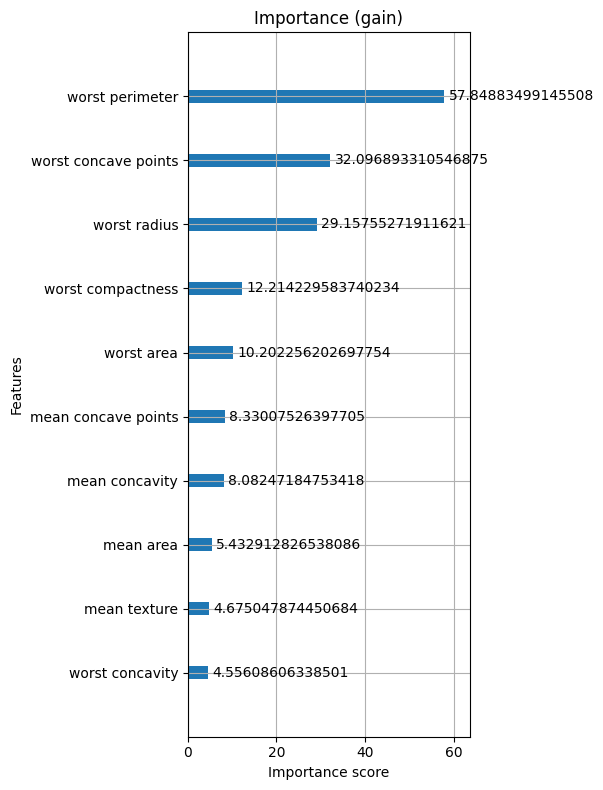

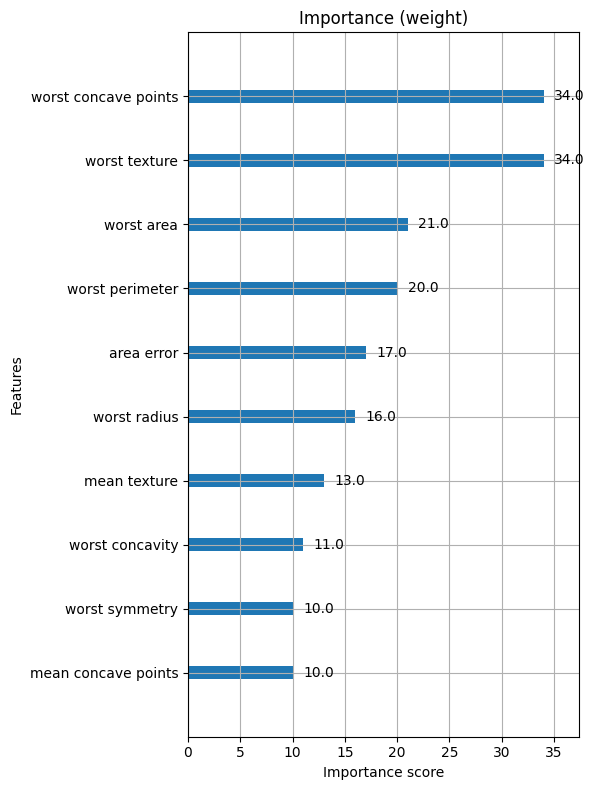

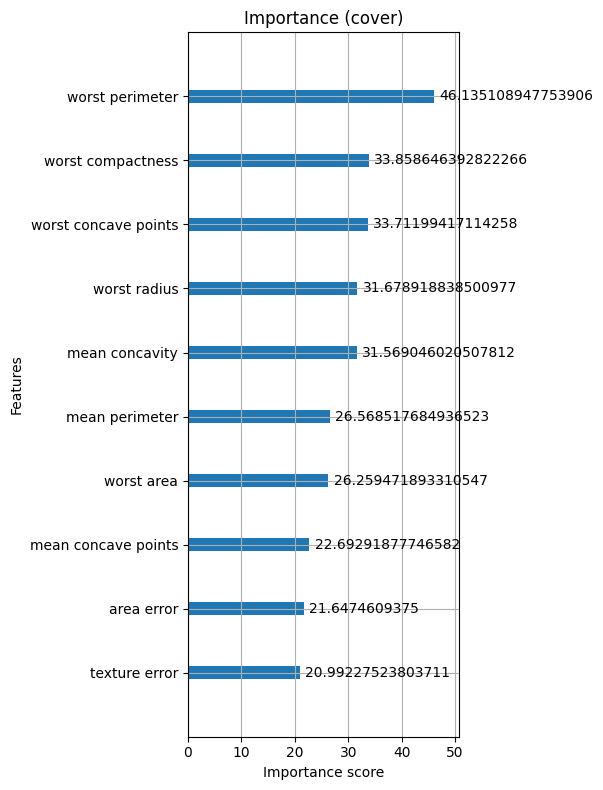

In [10]:
for imp in ("gain", "weight", "cover"):
    fig, ax = plt.subplots(figsize=(6, 8))
    xgb.plot_importance(clf.get_booster(), importance_type=imp,
                        max_num_features=10, ax=ax, title=f"Importance ({imp})")
    plt.tight_layout(); plt.savefig(f"importance_{imp}.png")

### 6. SHAP values — the preferred, consistent interpretation

/var/folders/vn/r3k_x1bj0yzdhv6ytv_fjtc40000gn/T/ipykernel_38223/3946255955.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)   # global importance + direction


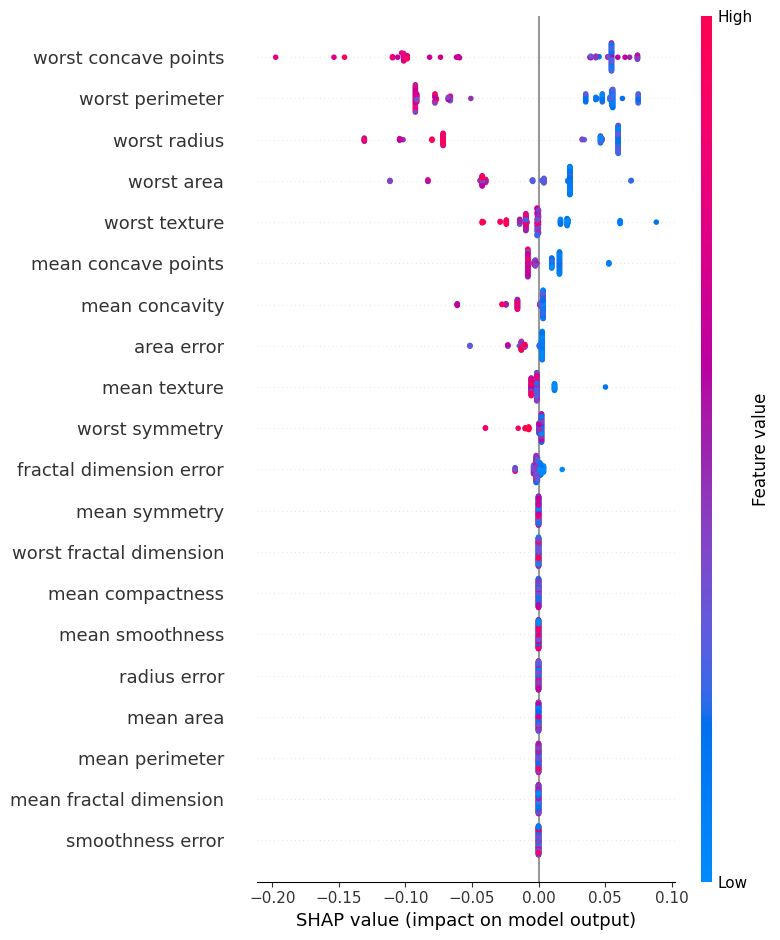

In [12]:
import shap
explainer = shap.TreeExplainer(clf)          # exact TreeSHAP for trees
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, show=False)   # global importance + direction
plt.tight_layout() #; plt.savefig("shap_summary.png")
plt.show()

### 7. Hyperparameter tuning with Optuna (Bayesian / TPE)

In [14]:
import optuna

def objective(trial):
    param = {
        "objective": "binary:logistic", "eval_metric": "aucpr",
        "tree_method": "hist", "random_state": 42,
        "n_estimators": 3000,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-8, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "early_stopping_rounds": 50,
    }
    model = xgb.XGBClassifier(**param)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    p = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, p)   # maximize AUC-PR

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)
print("Best params:", study.best_params, "| Best AUCPR:", study.best_value)

[I 2026-07-19 20:06:47,442] A new study created in memory with name: no-name-7f29c69d-e422-4019-bf1f-c5c6f7445786


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-19 20:06:47,499] Trial 0 finished with value: 0.9807431257569762 and parameters: {'learning_rate': 0.14387155515494796, 'max_depth': 5, 'min_child_weight': 18, 'subsample': 0.6345915698464977, 'colsample_bytree': 0.508642080229763, 'gamma': 0.018220056395554837, 'reg_lambda': 0.003910542561865164, 'reg_alpha': 2.691731737832218e-06}. Best is trial 0 with value: 0.9807431257569762.
[I 2026-07-19 20:06:47,582] Trial 1 finished with value: 0.9908651162104357 and parameters: {'learning_rate': 0.02048743581752541, 'max_depth': 7, 'min_child_weight': 3, 'subsample': 0.6277024671723237, 'colsample_bytree': 0.9404021595204244, 'gamma': 4.2623992397197095e-05, 'reg_lambda': 7.746521643664049, 'reg_alpha': 0.004293483573659558}. Best is trial 1 with value: 0.9908651162104357.
[I 2026-07-19 20:06:47,678] Trial 2 finished with value: 0.9931748827254923 and parameters: {'learning_rate': 0.03527236990399311, 'max_depth': 5, 'min_child_weight': 3, 'subsample': 0.8233598383886662, 'colsampl

### 8. Save & load  (use JSON/UBJSON — stable, portable format)

In [15]:
clf.save_model("bc_model.json")              # sklearn wrapper
booster.save_model("bc_booster.ubj")         # native, UBJSON (compact/stable)

loaded = xgb.XGBClassifier()
loaded.load_model("bc_model.json")
assert np.allclose(loaded.predict_proba(X_test)[:, 1], proba)
print("Model round-trip OK.")

Model round-trip OK.


## Calibration

mean p̂ = 0.625   prevalence = 0.632
ECE: 0.3299806463090997
slope: 12.922709112444203 intercept: -5.470759047258684
Brier: 0.18401286005973816  logloss: 0.5551862504815808


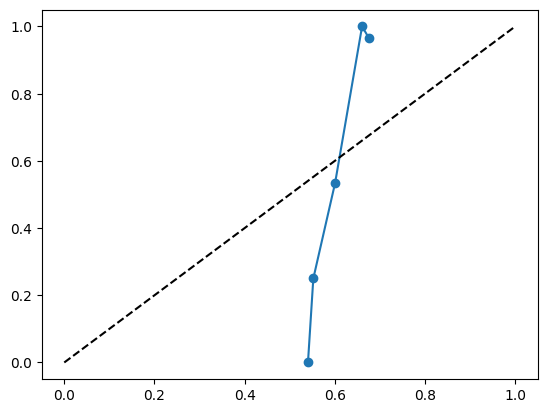

In [16]:
import numpy as np
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
from sklearn.linear_model import LogisticRegression

proba = clf.predict_proba(X_test)[:, 1]
y_t = np.asarray(y_test)

# (a) calibration-in-the-large: mean prediction vs prevalence
print(f"mean p̂ = {proba.mean():.3f}   prevalence = {y_t.mean():.3f}")

# (b) reliability curve, quantile bins
prob_true, prob_pred = calibration_curve(y_t, proba, n_bins=10, strategy="quantile")
plt.plot(prob_pred, prob_true, "o-"); plt.plot([0,1],[0,1],"k--")  # diagonal = perfect

# (c) ECE with the same binning
def ece(y, p, n_bins=10):
    q = np.quantile(p, np.linspace(0, 1, n_bins + 1))
    b = np.clip(np.searchsorted(q[1:-1], p), 0, n_bins - 1)
    return sum(np.mean(b==k) * abs(y[b==k].mean() - p[b==k].mean())
               for k in range(n_bins) if np.any(b==k))
print("ECE:", ece(y_t, proba))

# (d) calibration slope/intercept on the logit scale
z = np.log(np.clip(proba,1e-6,1-1e-6) / (1 - np.clip(proba,1e-6,1-1e-6)))
lr = LogisticRegression(C=1e6).fit(z.reshape(-1,1), y_t)   # C large ≈ unpenalized
print("slope:", lr.coef_[0,0], "intercept:", lr.intercept_[0])

# (e) proper scores
print("Brier:", brier_score_loss(y_t, proba), " logloss:", log_loss(y_t, proba))

In [17]:
from sklearn.frozen import FrozenEstimator            # sklearn >= 1.6
from sklearn.calibration import CalibratedClassifierCV

# carve a dedicated calibration split out of the training pool
X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_tr, y_tr, test_size=0.25, stratify=y_tr, random_state=0)

model = xgb.XGBClassifier(**clf.get_params())          # same hyperparameters
model.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], verbose=False)

cal = CalibratedClassifierCV(FrozenEstimator(model),   # freeze: don't refit the booster
                             method="sigmoid")         # Platt; 114-row calib set is
cal.fit(X_cal, y_cal)                                  # too small for isotonic
# (older sklearn: CalibratedClassifierCV(model, cv="prefit", method="sigmoid"))

p_cal = cal.predict_proba(X_test)[:, 1]
print("Brier before/after:", brier_score_loss(y_t, proba),
      brier_score_loss(y_t, p_cal))
print("AUCPR before/after:", average_precision_score(y_t, proba),
      average_precision_score(y_t, p_cal))   # ~unchanged: the map is monotone

Brier before/after: 0.18401286005973816 0.04573158889463229
AUCPR before/after: 0.9746319190815811 0.9921807846512695


### Check again

mean p̂ = 0.634   prevalence = 0.632


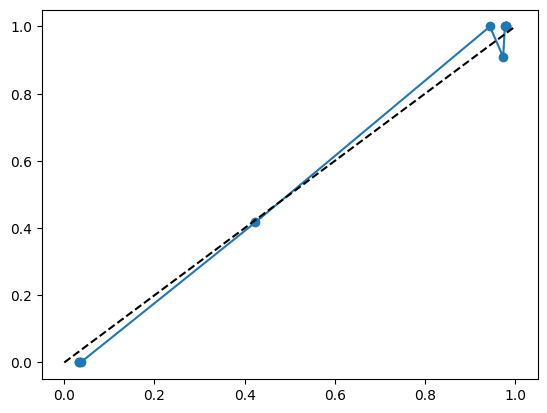

In [19]:
# (a) calibration-in-the-large: mean prediction vs prevalence
print(f"mean p̂ = {p_cal.mean():.3f}   prevalence = {y_t.mean():.3f}")

# (b) reliability curve, quantile bins
prob_true, prob_pred = calibration_curve(y_t, p_cal, n_bins=10, strategy="quantile")
plt.plot(prob_pred, prob_true, "o-"); plt.plot([0,1],[0,1],"k--")  # diagonal = perfect